In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
import matplotlib as mpl

# Global settings for publication-quality plots
mpl.rcParams.update({
    # Fonts
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica", "Arial", "DejaVu Sans"],
    "mathtext.fontset": "stix",
    "font.size": 9,          # Base font size
    "axes.titlesize": 10,    # Title font size
    "axes.labelsize": 9,     # X/Y label font size
    "xtick.labelsize": 8,    # Tick label font size
    "ytick.labelsize": 8,
    "legend.fontsize": 8,    # Legend font size

    # Line styles
    "lines.linewidth": 1.2,
    "lines.markersize": 4,

    # Axes
    "axes.linewidth": 0.8,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.size": 3,
    "ytick.major.size": 3,

    # Figure
    "figure.dpi": 300,
    "savefig.dpi": 600,
    "figure.figsize": (3.3, 2.5),  # ~1-column figure in most journals
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.02,
})

In [ ]:
BASEDIR = "./path_metad_data/"

In [ ]:
traj = np.loadtxt(BASEDIR+"metad_traj.dat")
cv_pd = pd.DataFrame({"t":traj[:, 0],  "s":traj[:, 1], "z":traj[:, 2],
                       "V_bias":traj[:, 3], "kBT":traj[:, 4],
                         "n_hills":traj[:, 5]})
cv_pd["weight"] = np.exp(cv_pd.V_bias/cv_pd.kBT)

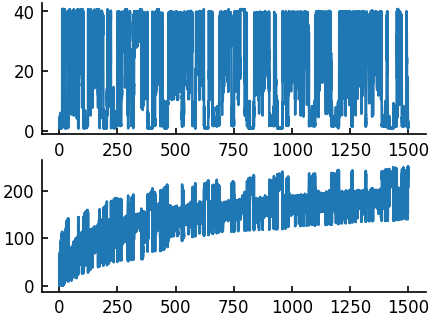

In [5]:
fig, ax = plt.subplots(2, 1, dpi=150)
ax[0].plot(cv_pd.t.to_numpy(), cv_pd.s.to_numpy())
ax[1].plot(cv_pd.t.to_numpy(), cv_pd.V_bias.to_numpy())
plt.show()

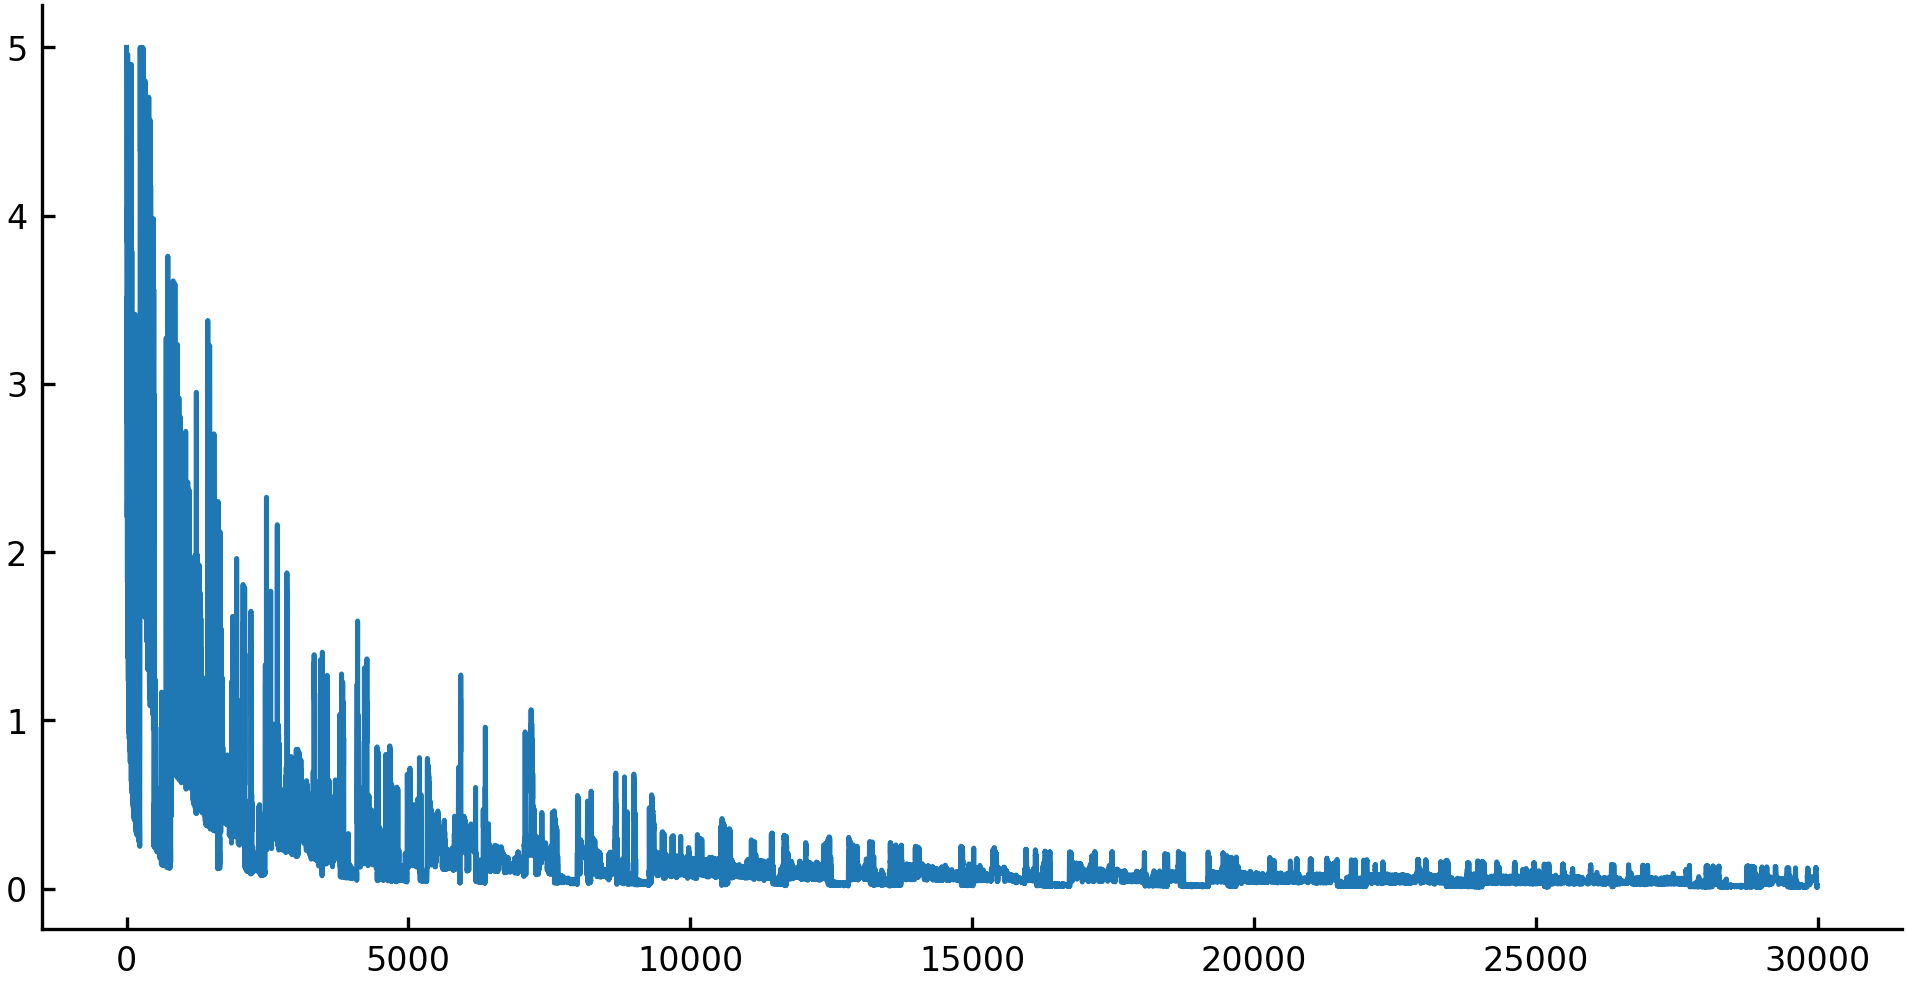

In [6]:
hills_traj = np.loadtxt(BASEDIR+"hills.dat")

fig, ax = plt.subplots(1, 1, figsize=(8, 4))
ax.plot(hills_traj[:, 1])

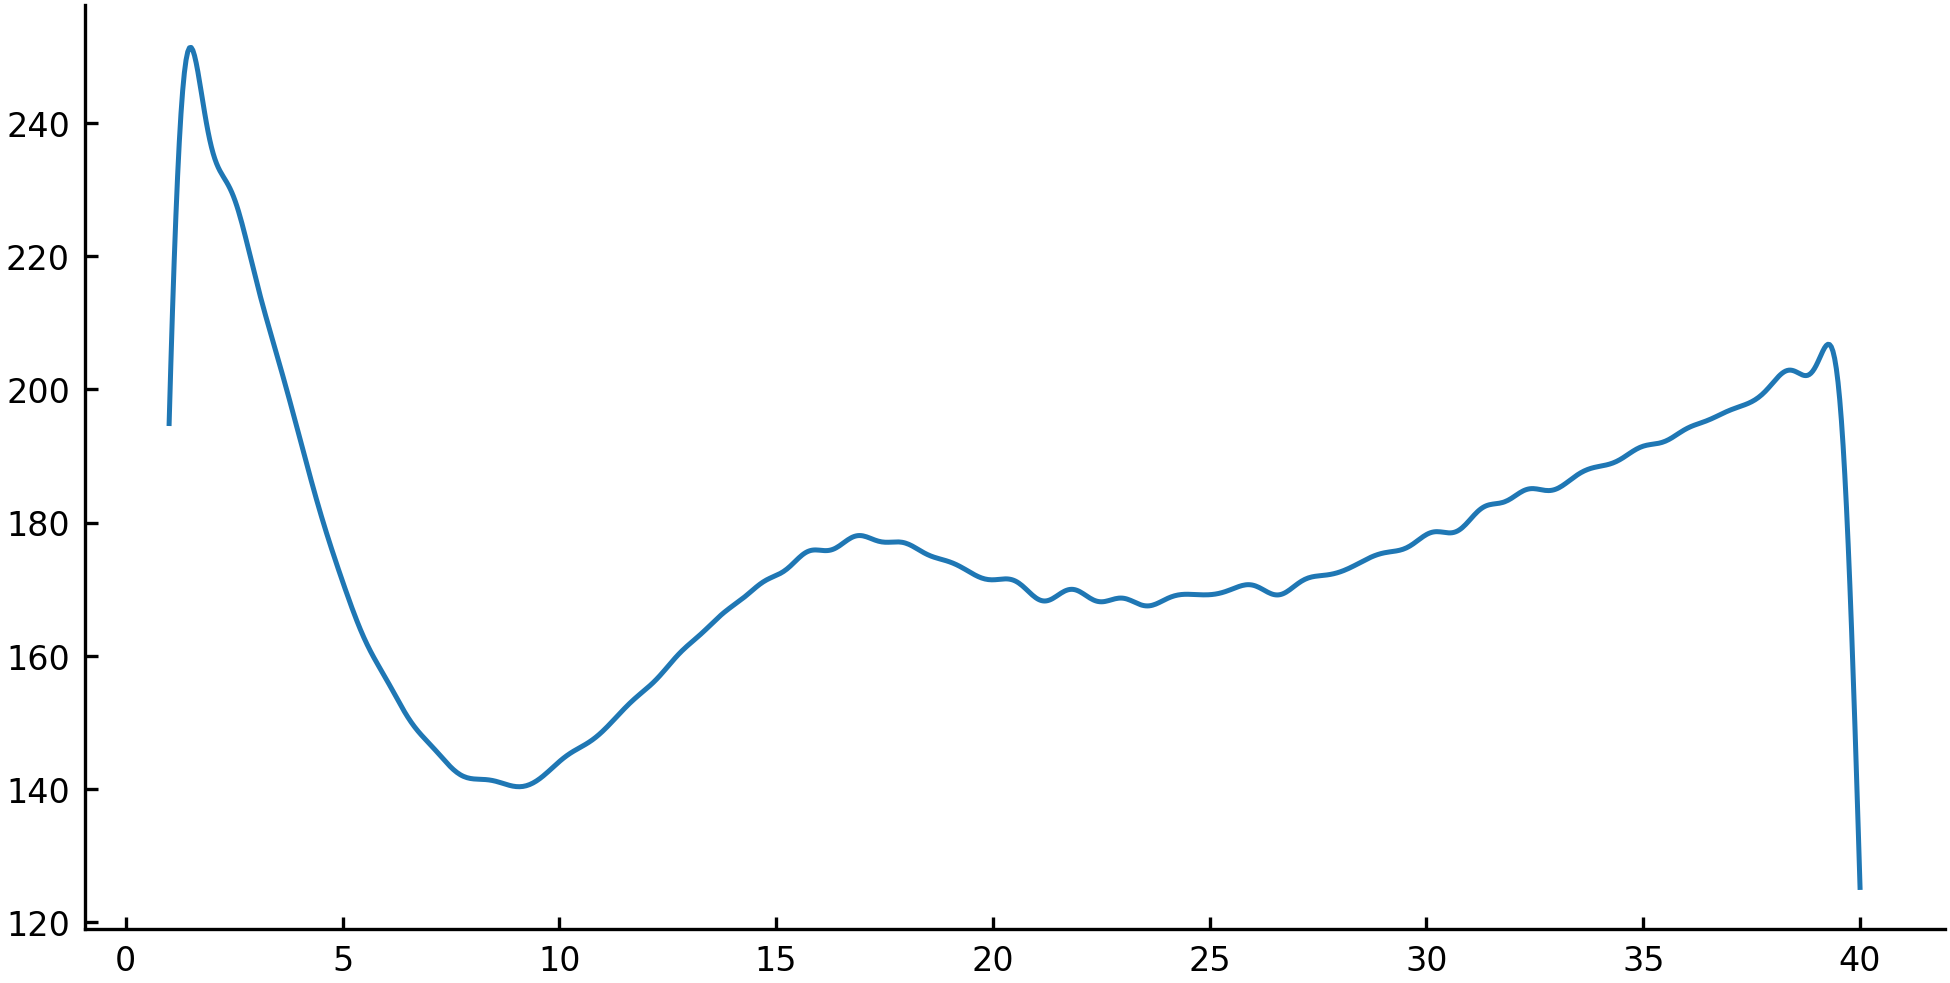

In [7]:
bias_grid = np.load(BASEDIR+'bias_grid.npy')

fig, ax = plt.subplots(1, 1, figsize=(8, 4))
xs = np.linspace(1, 40, 1000)
ax.plot(xs, bias_grid)

Free energy values at minima:
  Minimum 1 (-0.558, 1.442): F = 1.53
  Minimum 2 (0.624, 0.028): F = 55.94
  Minimum 3 (-0.050, 0.467): F = 68.75


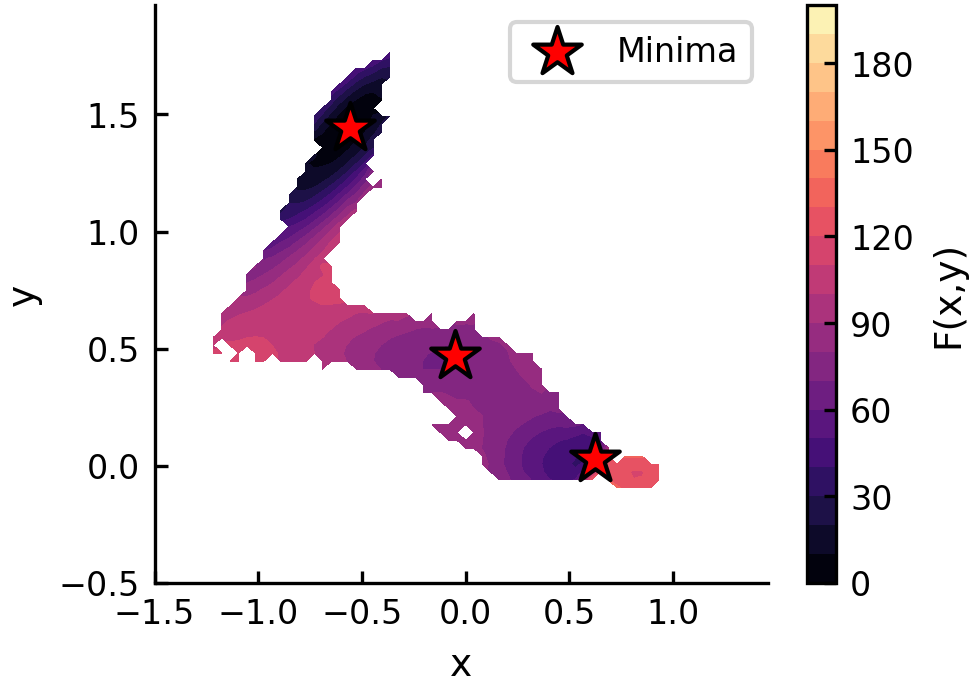

In [ ]:
# Load xy trajectory
traj_xy = np.loadtxt(BASEDIR + "metad_traj_xy.dat")
start_id = 30_000
x, y = traj_xy[start_id:, 1], traj_xy[start_id:, 2]
bias = np.interp(cv_pd.s.to_numpy()[start_id:], xs, bias_grid)

beta = 1.0 / cv_pd["kBT"].iloc[0]
weights = np.exp(beta*bias)

# 2D histogram with reweighting
x_edges = np.linspace(-1.5, 1.5, 75)
y_edges = np.linspace(-0.5, 2.0, 75)

hist, xedges, yedges = np.histogram2d(x, y, bins=[x_edges, y_edges], weights=weights)

# Convert to free energy
hist[hist == 0] = np.nan  # Avoid log(0)
F_xy = -1/beta * np.log(hist)
F_xy -= np.nanmin(F_xy)  # Shift minimum to zero

# Get F values at minima by interpolation                                                                                                                                                   
from scipy.interpolate import RegularGridInterpolator                                                                                                                                       

# Create interpolator (use bin centers)                                                                                                                                                     
x_centers = (xedges[:-1] + xedges[1:]) / 2                                                                                                                                                  
y_centers = (yedges[:-1] + yedges[1:]) / 2                                                                                                                                                  
interp = RegularGridInterpolator((x_centers, y_centers), F_xy, method='linear', bounds_error=False)                                                                                         

# Plot
fig, ax = plt.subplots(1, 1)
levels = np.linspace(0, 200, 21)
cf = ax.contourf(xedges[:-1], yedges[:-1], F_xy.T, levels=levels, cmap='magma')
plt.colorbar(cf, label='F(x,y)')

mins = np.array([[-0.5582,  1.4417],
                   [ 0.6235,  0.0280],
                   [-0.0500,  0.4667]])

for minim in mins:
    ax.scatter(minim[0], minim[1], s=150, c='red', marker='*', 
           edgecolors='black', linewidths=1, zorder=5)
    
# Evaluate F at each minimum                                                                                                                                                                
print("Free energy values at minima:")                                                                                                                                                      
for i, minim in enumerate(mins):                                                                                                                                                            
    F_val = interp(minim)[0]                                                                                                                                                                
    print(f"  Minimum {i+1} ({minim[0]:.3f}, {minim[1]:.3f}): F = {F_val:.2f}")
ax.set_xlabel('x')
ax.set_ylabel('y')
plt.legend(['Minima'])
plt.show()

In [10]:
from scipy.stats import gaussian_kde as kde

# Create interpolator (use bin centers)                                                                                                                                                     
kde_f = kde(np.vstack([x, y]), weights=weights, bw_method='silverman')

x_fine = np.linspace(x.min(), x.max(), 200)
y_fine = np.linspace(y.min(), y.max(), 200)

XX, YY = np.meshgrid(x_fine, y_fine)
grid_points = np.vstack([XX.ravel(), YY.ravel()])  # shape (2, 200*200)

pdf = kde_f(grid_points).reshape(200, 200)

F_xy = -1/beta * np.log(pdf)
min_shift = np.nanmin(F_xy)
F_xy -= min_shift  # Shift minimum to zero

/tmp/ipykernel_169303/1071393832.py:14: RuntimeWarning: divide by zero encountered in log
  F_xy = -1/beta * np.log(pdf)


Free energy values at minima and saddles:
  Point A: F = 0.70
  Point B: F = 68.81
  Point C: F = 54.34
  Point D: F = 76.45
  Point E: F = 108.23
Energy diffs: 
$\Delta G_{AB} = 68.1010174925963
$\Delta G_{BC} = -14.465773250956737
$\Delta G_{AD} = 75.74776934214152
$\Delta G_{BE} = 39.42220656034365


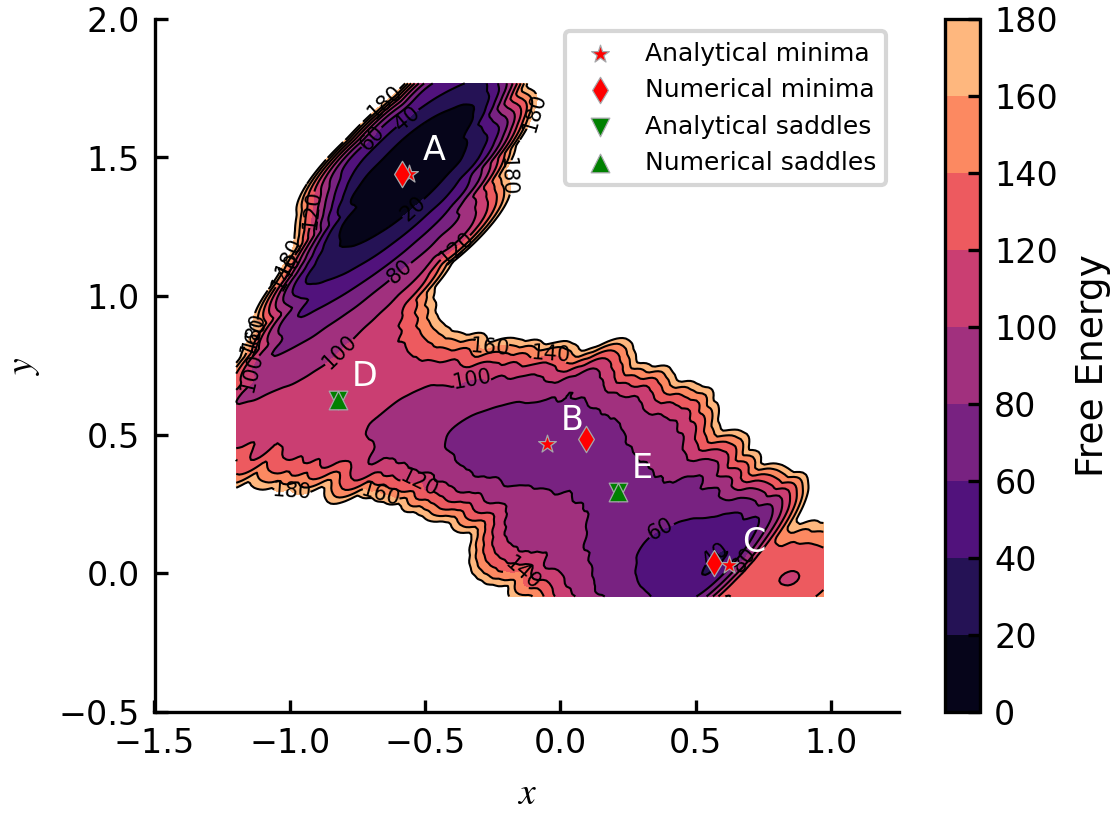

In [32]:
# Plot
fig, ax = plt.subplots(1, 1, figsize=(4, 3), dpi=300)

countour_levels = np.arange(0,200,20)

Z = np.where(F_xy<200, F_xy, np.nan)

cf = ax.contourf(XX, YY, Z, 
                 levels=countour_levels, cmap='magma', vmax=200)
plt.colorbar(cf, ax=ax, label='Free Energy')

ax.set_xlabel('x')
ax.set_ylabel('y')

# Add contour lines
contour_lines = ax.contour(XX, YY, Z, levels=countour_levels, 
                           colors='black', linewidths=0.5)
ax.clabel(contour_lines, inline=True, fontsize=5, colors='black')

mins = np.array([[-0.5582,  1.4417],
                   [ 0.6235,  0.0280],
                   [-0.0500,  0.4667]])


ax.scatter(mins[:, 0], mins[:, 1], s=20, c='red', marker='*', 
        edgecolors='#A6A8AB', linewidths=0.3, zorder=5, label="Analytical minima")

mins_found = np.array([[-0.587, 1.441],
                       [0.569, 0.037,],
                       [0.096, 0.483,]
                       ])

ax.scatter(mins_found[:, 0], mins_found[:, 1], s=20, c='red', marker='d', 
        edgecolors='#A6A8AB', linewidths=0.3, zorder=5, label="Numerical minima")

ax.text(*(mins[0]+0.05), 'A', color='w', fontsize=8)
ax.text(*(mins[1]+0.05), 'C', color='w', fontsize=8)
ax.text(*(mins[2]+0.05), 'B', color='w', fontsize=8)
    
saddles = np.array([[ 0.2125,  0.2930],
                    [-0.8220,  0.6243]])

ax.scatter(saddles[:, 0], saddles[:, 1], s=20, c='green', marker='v', zorder=5, 
           edgecolors='#A6A8AB', linewidths=0.3, label="Analytical saddles")

found_saddles = np.array([[0.165, 0.325],
                          [-0.762, 0.651,]
                          ])

ax.scatter(saddles[:, 0], saddles[:, 1], s=20, c='green', marker='^', zorder=5, 
           edgecolors='#A6A8AB', linewidths=0.3, label="Numerical saddles")

ax.text(*(saddles[0]+0.05), 'E', color='w', fontsize=8)
ax.text(*(saddles[1]+0.05), 'D', color='w', fontsize=8)
    
# Evaluate F at each minimum
F_vals = {}

def get_F_vals(x):
    e_val = kde_f(x)[0]
    F_val = -1/beta * np.log(e_val)
    F_val -= min_shift
    return F_val

F_vals["A"] = get_F_vals(mins[0])
F_vals["B"] = get_F_vals(mins[2])
F_vals["C"] = get_F_vals(mins[1])
F_vals["D"] = get_F_vals(saddles[0])
F_vals["E"] = get_F_vals(saddles[1])

print("Free energy values at minima and saddles:")                                                                                                                                                      
for point, val in F_vals.items():
    print(f"  Point {point}: F = {val:.2f}")

print("Energy diffs: ")
print(r"$\Delta G_{AB} = " + f"{F_vals['B'] - F_vals['A']}")
print(r"$\Delta G_{BC} = " + f"{F_vals['C'] - F_vals['B']}")
print(r"$\Delta G_{AD} = " + f"{F_vals['D'] - F_vals['A']}")
print(r"$\Delta G_{BE} = " + f"{F_vals['E'] - F_vals['B']}")

ax.set_xlabel(r'$x$')
ax.set_ylabel(r'$y$')
plt.legend(fontsize=6)
ax.set_xlim([-1.5, 1.25])
ax.set_ylim([-0.5, 2.0])
plt.savefig("muller_brown_reweighted_fes.png", dpi=300)
plt.show()

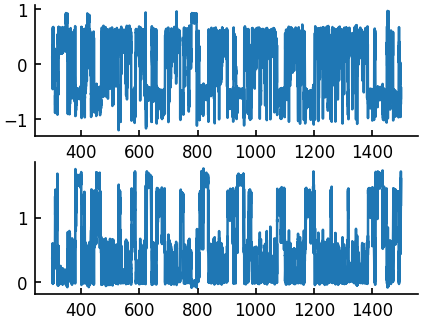

In [12]:
fig, ax = plt.subplots(2, 1, dpi=150)
ax[0].plot(cv_pd.t.to_numpy()[start_id:], x)
ax[1].plot(cv_pd.t.to_numpy()[start_id:], y)
plt.show()

In [14]:
from skimage.feature import peak_local_max

# F_xy has NaNs where KDE is ~0; replace with large value so they're ignored
F_safe = np.where(np.isfinite(F_xy), F_xy, np.nanmax(F_xy))

# Find local minima = local maxima of -F
coords = peak_local_max(
    -F_safe,
    min_distance=10,      # minimum pixel separation between minima
    num_peaks=3,          # return top 3 deepest minima
)

# coords are (row, col) indices — convert to (x, y) values
x_mins = x_fine[coords[:, 1]]
y_mins = y_fine[coords[:, 0]]
F_mins = F_xy[coords[:, 0], coords[:, 1]]

for i, (xi, yi, fi) in enumerate(zip(x_mins, y_mins, F_mins)):
    print(f"Min {i+1}: x={xi:.3f}, y={yi:.3f}, F={fi:.3f}")

Min 1: x=-0.587, y=1.441, F=0.000
Min 2: x=0.569, y=0.037, F=37.966
Min 3: x=-0.096, y=0.483, F=67.990


In [20]:
from scipy.ndimage import gaussian_filter
from skimage.feature import peak_local_max
import numpy as np

# 1. Smooth F_xy to reduce numerical noise before taking derivatives
sigma = 10.0  # pixels; increase if too many spurious saddles
F_smooth = gaussian_filter(F_safe, sigma=sigma)

# 2. Compute finite-difference gradients
dF_dy, dF_dx = np.gradient(F_smooth)          # shape (200, 200) each
grad_mag = np.sqrt(dF_dx**2 + dF_dy**2)

# 3. Compute Hessian components
d2F_dy2, d2F_dx2 = np.gradient(dF_dx)         # note: np.gradient returns (row, col)
_, d2F_dxdy    = np.gradient(dF_dy)

# Hessian determinant: det < 0 ↔ saddle point
hess_det = d2F_dx2 * d2F_dy2 - d2F_dxdy**2

# 4. Saddle mask: small gradient AND negative Hessian determinant
grad_threshold  = np.nanpercentile(grad_mag, 5)   # bottom 15% of gradient magnitudes
saddle_mask = (grad_mag < grad_threshold) & (hess_det < 0) & np.isfinite(F_xy)

# 5. Among candidate pixels, find local minima of |∇F| to get the sharpest critical points
grad_in_mask = np.where(saddle_mask, grad_mag, np.nanmax(grad_mag))
coords = peak_local_max(-grad_in_mask, min_distance=10, num_peaks=5)

# 6. Filter: keep only those with det(H) < 0 (saddles, not noise)
saddles = []
for r, c in coords:
    if hess_det[r, c] < 0:
        saddles.append({
            "x": x_fine[c],
            "y": y_fine[r],
            "F": F_xy[r, c],
            "det_H": hess_det[r, c],
        })

for i, s in enumerate(saddles):
    print(f"Saddle {i+1}: x={s['x']:.3f}, y={s['y']:.3f}, F={s['F']:.3f}")

Saddle 1: x=0.165, y=0.325, F=77.180
Saddle 2: x=-0.762, y=0.651, F=107.625
Saddle 3: x=0.438, y=0.037, F=46.139


/tmp/ipykernel_169303/933175950.py:18: RuntimeWarning: invalid value encountered in subtract
  hess_det = d2F_dx2 * d2F_dy2 - d2F_dxdy**2
